
Class Distribution:
critical_status
Critical        864
Non-Critical    136
Name: count, dtype: int64

Example Test Results:
State: (1, 2, 4, 4) -> Recommended action: decrease_qos
State: (5, 0, 1, 1) -> Recommended action: increase_frequency
State: (3, 1, 3, 2) -> Recommended action: increase_qos

Final Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.99      0.99       864
Non-Critical       0.93      1.00      0.96       136

    accuracy                           0.99      1000
   macro avg       0.96      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000



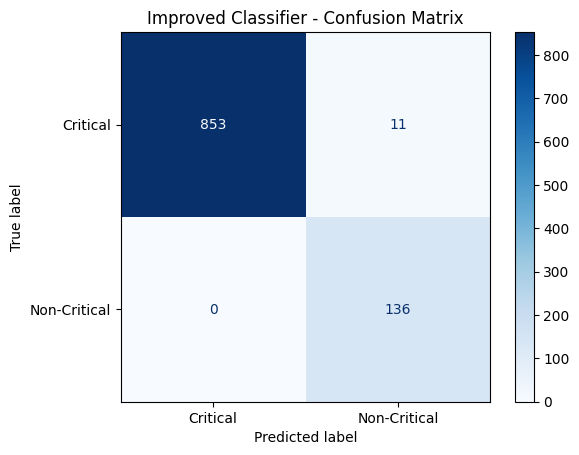

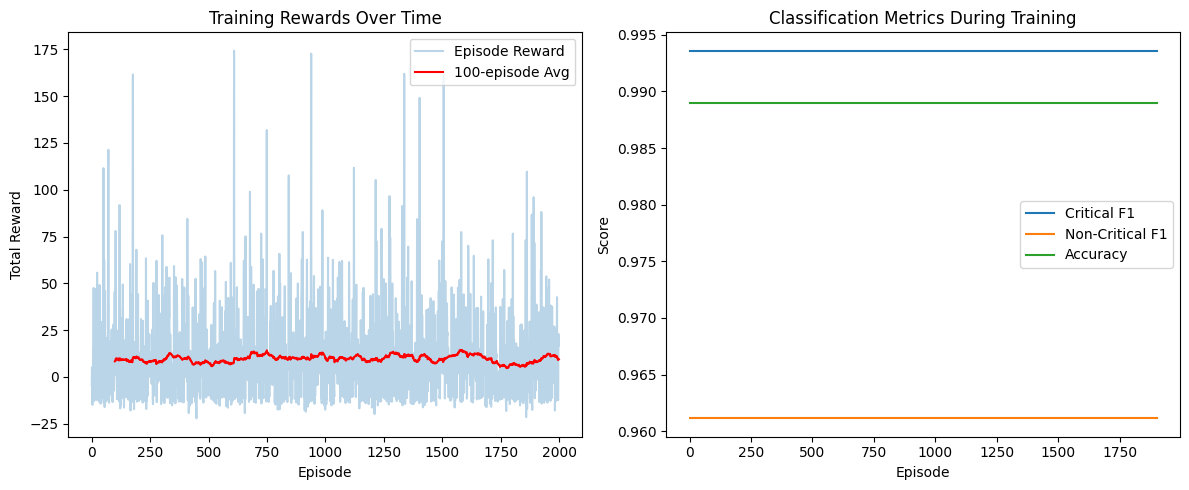

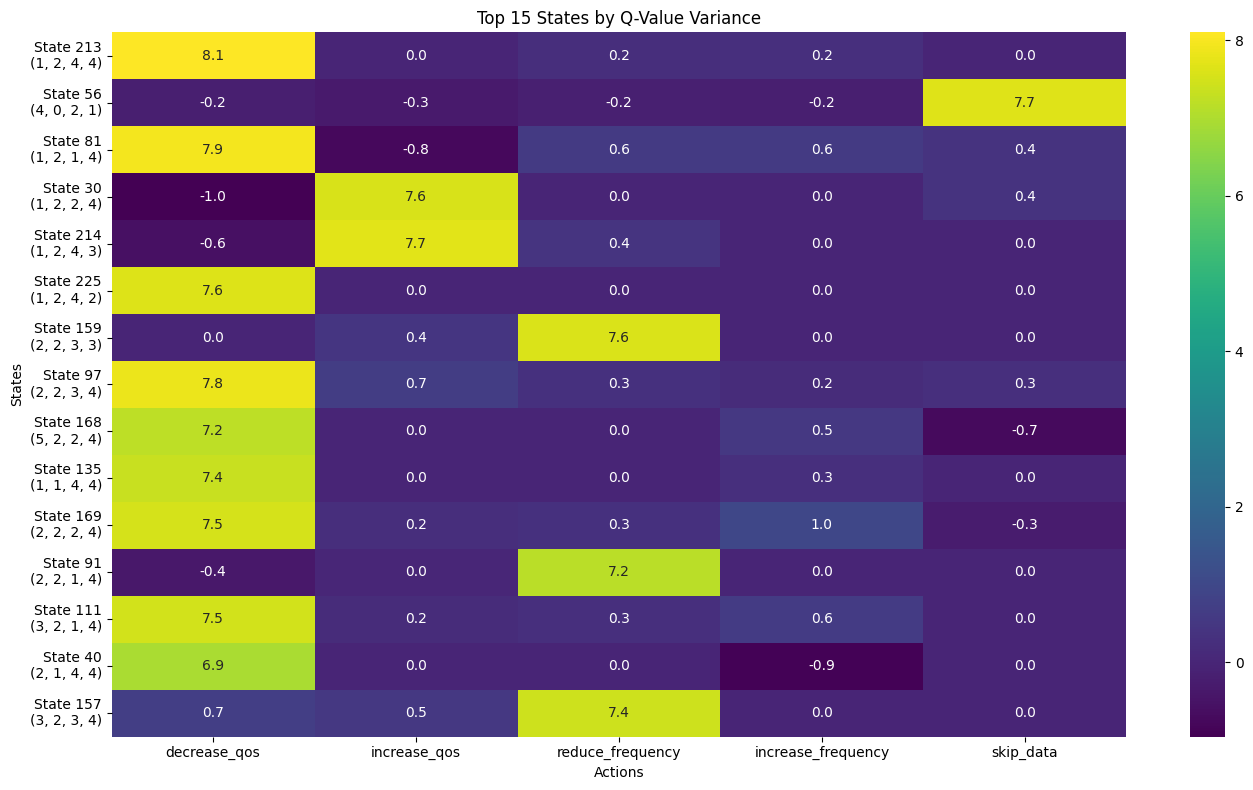

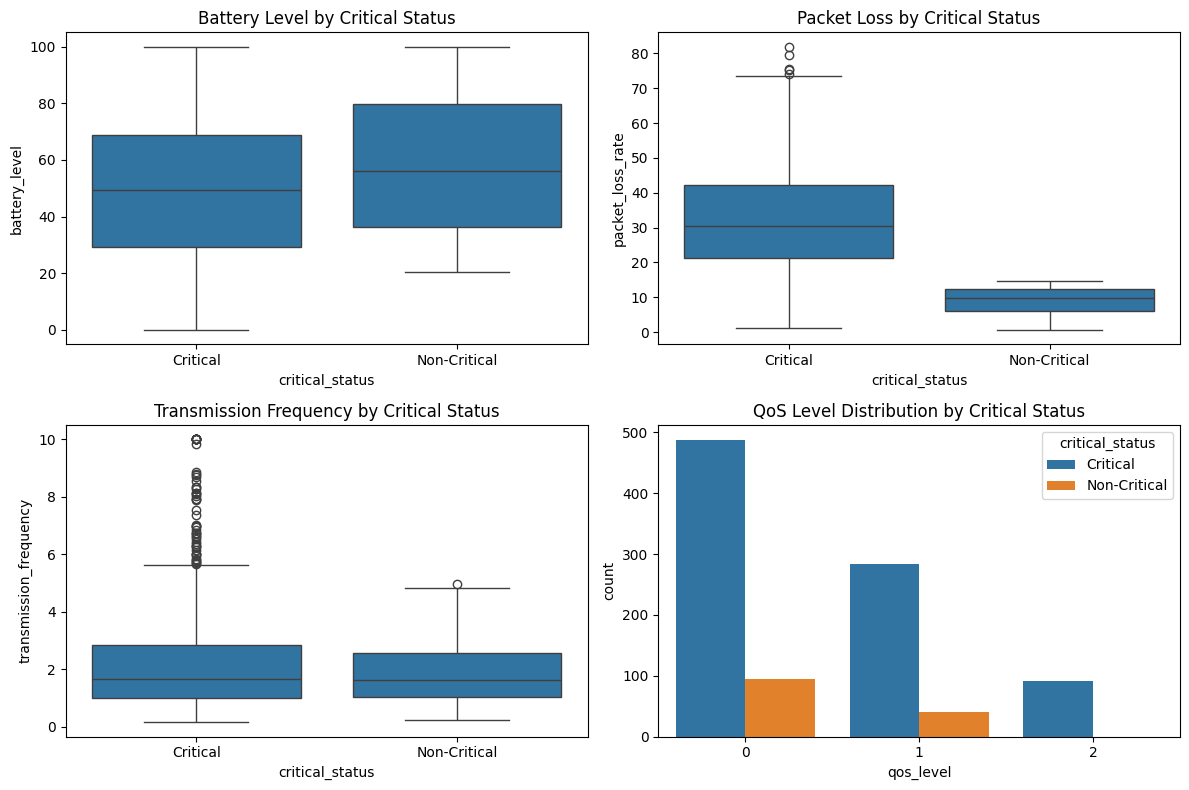

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

# Data Generation: Synthetic one
np.random.seed(42)
n_samples = 1000

# Generate synthetic data
data = {
    'battery_level': np.clip(np.random.normal(loc=50, scale=30, size=n_samples), 0, 100),
    'qos_level': np.random.choice([0, 1, 2], size=n_samples, p=[0.6, 0.3, 0.1]),
    'transmission_frequency': np.clip(np.random.lognormal(mean=0.5, sigma=0.8, size=n_samples), 0.1, 10),
    'packet_delay': np.random.gamma(shape=2, scale=50, size=n_samples),
    'packet_loss_rate': np.random.beta(a=2, b=5, size=n_samples) * 100,
    'message_size': np.random.randint(64, 1025, size=n_samples),
}

# Calculate power consumption
data['power_consumption_rate'] = (
    (data['transmission_frequency'] * data['message_size'] * 0.001) +
    (data['qos_level'] * 0.2) +
    np.random.normal(0, 0.1, size=n_samples)
)

# Create DataFrame
df = pd.DataFrame(data)

# Define critical state thresholds
critical_conditions = (
    (df['battery_level'] < 20) |                # Low battery
    (df['packet_loss_rate'] > 15) |             # High packet loss
    (df['packet_delay'] > 200) |                # High latency
    (df['transmission_frequency'] > 5) |        # High transmission frequency
    (df['qos_level'] == 2)                      # Using highest QoS level
)

# Add classification labels
df['critical_status'] = np.where(
    critical_conditions, 'Critical', 'Non-Critical')

# Save to CSV
df.to_csv('iot_system_data.csv', index=False)
# Display sample data's class distribution
print("\nClass Distribution:")
print(df['critical_status'].value_counts())

# State discretization function


def discretize_state(row):
    # Discretize continuous features
    battery_bins = [0, 20, 40, 60, 80, 100]
    freq_bins = [0, 1, 3, 5, 10]
    loss_bins = [0, 5, 10, 15, 100]

    return (
        np.digitize(row['battery_level'], battery_bins),
        row['qos_level'],
        np.digitize(row['transmission_frequency'], freq_bins),
        np.digitize(row['packet_loss_rate'], loss_bins),
    )


df['state'] = df.apply(discretize_state, axis=1)

# Q learning setup
# Define action space
actions = {
    0: 'decrease_qos',
    1: 'increase_qos',
    2: 'reduce_frequency',
    3: 'increase_frequency',
    4: 'skip_data'
}

# Q-Learning parameters
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.3  # Higher initial exploration
min_epsilon = 0.01  # Minimum exploration rate
epsilon_decay = 0.995 # Decay rate for exploration

# Class weights for handling imbalance
class_counts = df['critical_status'].value_counts()
class_weights = {
    'Critical': 1.0, # Critical class weight
    'Non-Critical': class_counts['Critical'] / class_counts['Non-Critical'] # Non-Critical class weight
}

# Initialize Q-table
all_states = list(df['state'].unique())
state_space = list(set(all_states))
action_space = list(actions.keys())
q_table = np.zeros((len(state_space), len(action_space)))

# Create state mapping
state_to_idx = {state: i for i, state in enumerate(state_space)}

# =Improved Q-learning training loop


def predict_status(state):
    """Improved status prediction using state components"""
    battery, qos, freq, loss = state

    if (battery < 2 or      # Low battery (bin 1 = 0-20%)
        loss > 3 or         # High packet loss (bin 4 = 15-100%)
        qos == 2 or         # Highest QoS level
            freq > 3):          # High frequency (bin 4 = 5-10 Hz)
        return 'Critical'
    return 'Non-Critical'


def calculate_reward(new_state, action, actual_status=None):
    """Enhanced reward function with classification component"""
    battery, qos, freq, loss = new_state

    # Base reward components
    reward = 0

    # Battery conservation (higher is better)
    reward += (battery / 5) * 0.3  # Max 1.5

    # Network stability (lower loss is better)
    reward -= (loss / 4) * 0.3     # Max -0.75

    # Energy efficiency (lower frequency is better)
    reward -= (freq / 4) * 0.2     # Max -0.5

    # Action cost penalty
    if action in [1, 3]:  # Actions that increase resource usage
        reward -= 0.3
    elif action == 4:     # Data skipping
        reward -= 0.5

    # Classification reward if actual status is provided
    if actual_status is not None:
        predicted_status = predict_status(new_state)
        if predicted_status == actual_status:
            reward += 2.0 * class_weights.get(actual_status, 1.0)
        else:
            reward -= 2.0 * class_weights.get(actual_status, 1.0)

    return reward


# Training loop
n_episodes = 2000  # Increased number of episodes
history = []
classification_reports = []

for episode in range(n_episodes):
    # Select random initial state with its label
    sample = df.sample(1)
    current_state = sample['state'].values[0]
    actual_status = sample['critical_status'].values[0]

    total_reward = 0
    done = False

    while not done:
        # Epsilon-greedy action selection
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.choice(action_space)
        else:
            if current_state not in state_to_idx:
                state_to_idx[current_state] = len(state_space)
                state_space.append(current_state)
                q_table = np.vstack([q_table, np.zeros(len(action_space))])
            state_idx = state_to_idx[current_state]
            action = np.argmax(q_table[state_idx])

        # Simulate action outcome with more realistic transitions
        new_state = (
            current_state[0] + np.random.choice([-1, 0, 1], p=[0.3, 0.4, 0.3]),
            current_state[1] + np.random.choice([-1, 0, 1], p=[0.2, 0.6, 0.2]),
            current_state[2] + np.random.choice([-1, 0, 1], p=[0.3, 0.4, 0.3]),
            current_state[3] + np.random.choice([-1, 0, 1], p=[0.3, 0.4, 0.3]),
        )

        # Clip to valid ranges
        new_state = (
            np.clip(new_state[0], 1, 5),
            np.clip(new_state[1], 0, 2),
            np.clip(new_state[2], 1, 4),
            np.clip(new_state[3], 1, 4),
        )

        # Add new state to Q-table if not exists
        if new_state not in state_to_idx:
            state_to_idx[new_state] = len(state_space)
            state_space.append(new_state)
            q_table = np.vstack([q_table, np.zeros(len(action_space))])

        # Calculate reward with classification component
        reward = calculate_reward(new_state, action, actual_status)
        total_reward += reward

        # Q-table update
        old_state_idx = state_to_idx[current_state]
        new_state_idx = state_to_idx[new_state]

        q_table[old_state_idx, action] = (1 - alpha) * q_table[old_state_idx, action] + \
            alpha * (reward + gamma * np.max(q_table[new_state_idx]))

        current_state = new_state

        # Episode termination conditions
        if np.random.random() < 0.05 or total_reward < -10:
            done = True

    history.append(total_reward)

    # Decay exploration rate
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    # Periodic evaluation
    if episode % 100 == 0:
        y_true = df['critical_status']
        y_pred = [predict_status(row['state']) for _, row in df.iterrows()]
        reports = classification_report(y_true, y_pred, output_dict=True)
        classification_reports.append({
            'episode': episode,
            'accuracy': reports['accuracy'],
            'f1_critical': reports['Critical']['f1-score'],
            'f1_non_critical': reports['Non-Critical']['f1-score']
        })

# Example test results
print("\nExample Test Results:")

# Define a few example states (picking up realistic test cases)
test_states = [
    (1, 2, 4, 4),  # Critical state (low battery, highest QoS, high freq/loss)
    (5, 0, 1, 1),  # Non-Critical state (good battery, low QoS, low freq/loss)
    (3, 1, 3, 2),  # Medium/Borderline state
]

# Predict recommended action for each test state
for state in test_states:
    if state in state_to_idx:
        state_idx = state_to_idx[state]
        best_action = actions[np.argmax(q_table[state_idx])]
    else:
        best_action = "reduce_frequency (default — unseen state)"
    print(f"State: {state} -> Recommended action: {best_action}")

# Evaluation
# Final classification report
y_true = df['critical_status']
y_pred = [predict_status(row['state']) for _, row in df.iterrows()]

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=['Critical', 'Non-Critical'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Critical', 'Non-Critical'])
disp.plot(cmap='Blues')
plt.title('Improved Classifier - Confusion Matrix')
plt.show()

# Visualization of results
# 1. Training progress
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history, alpha=0.3, label='Episode Reward')
plt.plot(pd.Series(history).rolling(100).mean(), 'r-', label='100-episode Avg')
plt.title('Training Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()

# Classification metrics over training
plt.subplot(1, 2, 2)
reports_df = pd.DataFrame(classification_reports)
plt.plot(reports_df['episode'], reports_df['f1_critical'], label='Critical F1')
plt.plot(reports_df['episode'],
         reports_df['f1_non_critical'], label='Non-Critical F1')
plt.plot(reports_df['episode'], reports_df['accuracy'], label='Accuracy')
plt.title('Classification Metrics During Training')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Q-table visualization (top important states)
state_variances = np.var(q_table, axis=1)
top_state_indices = np.argsort(state_variances)[-15:][::-1]

plt.figure(figsize=(14, 8))
sns.heatmap(
    q_table[top_state_indices],
    cmap="viridis",
    annot=True,
    fmt=".1f",
    xticklabels=[actions[a] for a in actions],
    yticklabels=[f"State {i}\n{state_space[i]}" for i in top_state_indices]
)
plt.title('Top 15 States by Q-Value Variance')
plt.xlabel('Actions')
plt.ylabel('States')
plt.tight_layout()
plt.show()

# 3. Feature distributions by critical status
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x='critical_status', y='battery_level', data=df)
plt.title('Battery Level by Critical Status')

plt.subplot(2, 2, 2)
sns.boxplot(x='critical_status', y='packet_loss_rate', data=df)
plt.title('Packet Loss by Critical Status')

plt.subplot(2, 2, 3)
sns.boxplot(x='critical_status', y='transmission_frequency', data=df)
plt.title('Transmission Frequency by Critical Status')

plt.subplot(2, 2, 4)
sns.countplot(x='qos_level', hue='critical_status', data=df)
plt.title('QoS Level Distribution by Critical Status')
plt.tight_layout()
plt.show()